<a href="https://colab.research.google.com/github/paulagirones/Aerogels_thermal_conductivity/blob/main/aerogels_thermal_conductivity_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aerogels thermal conductivity

RAW DATA
   ↓
DATA CLEANING              ← ESTÁS AQUÍ
   ↓
EDA                        ← SIGUIENTE
   ↓
FEATURE SELECTION
   ↓
TRAIN / TEST SPLIT
   ↓
ML PREPROCESSING
   ↓
BASELINE MODEL
   ↓
MODEL COMPARISON
   ↓
FEATURE IMPORTANCE
   ↓
FINAL MODEL

# LIBRARIES

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# DATA EXPLORATION

In [71]:

# Load the dataset
df_raw = pd.read_csv('20250220_dataset.csv')

# Working copy
df = df_raw.copy()
# Inspect the first rows
print("First 5 rows:")
display(df.head())

# Display information about the dataset
print("\nDataset information:")
df.info()



First 5 rows:


,Entry,Drying,Purpose,Shape,First materials,Second materials,Modification,First material class,Second materials class,Modification class,...,BET surface area m2/g,BJH pore size nm,BJH pore volume (total) cm3/g,compression elastic modulus MPa,SEM,Thermal conductivity W/(m K),Thermal method,Thermal method detail,Unnamed: 28,Unnamed: 29
0,1,SCD,Not specific,Monolith?,Soda soap,NaN,NaN,Q,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,185.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,185.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,FD,Not specific,Monolith,Polystyrene,NaN,NaN,J,NaN,NaN,...,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16559 entries, 0 to 16558
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Entry                            16559 non-null  int64  
 1   Drying                           16559 non-null  object 
 2   Purpose                          16559 non-null  object 
 3   Shape                            16559 non-null  object 
 4   First materials                  16559 non-null  object 
 5   Second materials                 6368 non-null   object 
 6   Modification                     3086 non-null   object 
 7   First material class             16559 non-null  object 
 8   Second materials class           6368 non-null   object 
 9   Modification class               3082 non-null   object 
 10  Gelation class                   16559 non-null  object 
 11  Solvent class                    16559 non-null  object 
 

# CLEANING

In [72]:
# Check Porosity type
print('Porosity type:')
print(df['Porosity'].dtype)
print(df['Porosity'].unique()[:20])

# Check SEM type
print('SEM type:')
print(df['SEM'].dtype)
print(df['SEM'].unique()[:20])


# Check Unnamed:29 type and content
print('Unnamed: 29 column content:')
print(df['Unnamed: 29'].dtype)
print(df['Unnamed: 29'].unique())


Porosity type:
object
[nan '95%' '94%' '98%' '96%' '97%' '65%' '74.38%' '80.75%' '84.19%'
 '88.06%' '87.45%' '82.64%' '78.32%' '67.97%' '32.80%' '48.20%' '53.70%'
 '59.30%' '65.90%']
SEM type:
object
[nan 'Mesoporous (nanoparticulate)' 'Macroporous (cellular)' 'Mesoporous?'
 'Macroporous (flakes)' 'Macroporous (particulate)'
 'Macroporous (fibrous)' 'Macroporous (fibrous and particulate)'
 'Mesoporous (nanofibrous)' 'Microparticles'
 'Macroporous (cellular and fibrous)'
 'Mesoporous (nanofibrous and nanoparticulate)'
 'Macroporous (cellular and flakes)' 'Macroporous (fibrous and flakes)'
 'Macroporous (nanoparticulate)' 'Macroporous (cellular and particulate)'
 'Macroporous (flakes and particulate)' 'Macroporous' 'Macroporous?'
 'Macroporous (nanofibrous)']
Unnamed: 29 column content:
object
[nan 'kokoko' 'koko' 'kokokoko' 'kokokokoko']


In [73]:
#Fix porosity type (it is numeric)
df['Porosity'] = (
    df['Porosity']
    .str.replace('%', '', regex=False)
    .astype(float)
)

display(df.loc[df['Porosity'].notna(), ['Porosity']].head(10))

# Remove empty and wrong columns
df = df.drop(columns=['Unnamed: 28', 'Unnamed: 29'])

,Porosity
148,95.0
149,95.0
150,95.0
151,94.0
239,98.0
240,96.0
241,97.0
242,98.0
243,97.0
244,95.0


In [74]:
# Check missing values
missing = pd.DataFrame({
    'Missing values': df.isna().sum(),
    'Missing (%)': df.isna().mean() * 100
})
display(missing.sort_values('Missing (%)', ascending=False))

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

,Missing values,Missing (%)
Post-drying cross-linking,16064,97.010689
BJH pore size nm,15547,93.888520
BJH pore volume (total) cm3/g,14080,85.029289
Thermal conductivity W/(m K),14075,84.999094
Thermal method detail,14069,84.962860
Thermal method,14066,84.944743
compression elastic modulus MPa,13558,81.876925
Modification class,13477,81.387765
Modification,13473,81.363609
Post drying treatment,13264,80.101455


Duplicate rows: 0


In [75]:
#Rename columns
df = df.rename(columns={
    'Thermal conductivity W/(m K)': 'Thermal_conductivity',
    'Envelope density g/cm3': 'Density',
    'BET surface area m2/g': 'BET',
    'BJH pore size nm': 'Pore_size',
    'BJH pore volume (total) cm3/g': 'Pore_volume',
    'compression elastic modulus MPa': 'Elastic_modulus'
})

# Remove samples without a measured thermal conductivity (our target)
df = df.dropna(subset=['Thermal_conductivity'])

# Display categories and number of unique values
categorical_columns = df.select_dtypes(include='object').columns
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(f"Number of categories: {df[col].nunique()}")
    print(df[col].unique()[:10])


--- Drying ---
Number of categories: 5
['SCD' 'FD' 'APD' 'VD' 'Foaming']

--- Purpose ---
Number of categories: 28
['Thermal insulation' 'Not specific'
 'Sound insulation, thermal insulation' 'Adsorbent' 'Filters' 'Separation'
 'Adsorbent (gas)' 'Thermoelectric devices' 'Steam generation'
 'Separation, thermal insulation']

--- Shape ---
Number of categories: 11
['Monolith' 'Fibers, monolith' 'Monolith ' 'Sheet' 'Fibers'
 'Monolith, sheet' 'Monolith (3D)' 'Beads, monolith' 'Beads' 'FIbers']

--- First materials ---
Number of categories: 90
['RF' 'Phenolic resin' 'Polyisocyanurate' 'Polyurethane'
 'Polydicyclopentadiene' 'Poly(urea-urethane)' 'Aramid fibers' 'Polyimide'
 'Lignocellulose' 'Cellulose']

--- Second materials ---
Number of categories: 123
[nan 'PVA, GO' 'Lignin' 'PMMA' 'Aramid' 'Silicone resin'
 'Silicone resin, cork' 'Phenolic resin' 'Starch' 'SiO2']

--- Modification ---
Number of categories: 63
[nan 'MTMS treatment' 'Fluorosilan modification' 'Carbonized'
 '3-Aminopropy

In [76]:
# Remove leading and trailing whitespace from categorical variables

for col in categorical_columns:
    df[col] = df[col].str.strip()

# Check for inconsistencies caused by capitalization
for col in categorical_columns:
    normalized = (
        df[col]
        .str.lower()
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

    print(
        f"{col}: "
        f"{df[col].nunique()} original -> "
        f"{normalized.nunique()} normalized categories"
    )

Drying: 5 original -> 5 normalized categories
Purpose: 28 original -> 27 normalized categories
Shape: 10 original -> 9 normalized categories
First materials: 90 original -> 90 normalized categories
Second materials: 123 original -> 122 normalized categories
Modification: 63 original -> 63 normalized categories
First material class: 16 original -> 16 normalized categories
Second materials class: 56 original -> 56 normalized categories
Modification class: 7 original -> 7 normalized categories
Gelation class: 9 original -> 9 normalized categories
Solvent class: 8 original -> 8 normalized categories
Process: 2193 original -> 2193 normalized categories
Gelation mechanism: 29 original -> 28 normalized categories
Final solvent: 31 original -> 31 normalized categories
Drying details: 12 original -> 12 normalized categories
Post drying treatment: 136 original -> 136 normalized categories
Post-drying cross-linking: 3 original -> 3 normalized categories
SEM: 20 original -> 20 normalized categorie

In [77]:
# Find categories that differ only by capitalization

for col in categorical_columns:

    normalized = (
        df[col]
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.lower()
    )

    temp = pd.DataFrame({
        'original': df[col],
        'normalized': normalized
    }).drop_duplicates()

    duplicates = (
        temp.groupby('normalized')['original']
        .agg(list)
    )

    duplicates = duplicates[
        duplicates.apply(lambda x: len(x) > 1)
    ]

    if not duplicates.empty:
        print(f"\n--- {col} ---")
        for normalized_value, original_values in duplicates.items():
            print(f"{original_values} -> '{normalized_value}'")


--- Purpose ---
['Separation, thermal insulation', 'Separation, thermal Insulation'] -> 'separation, thermal insulation'

--- Shape ---
['Fibers', 'FIbers'] -> 'fibers'

--- Second materials ---
['Aramid fibers, MXene', 'Aramid fibers, Mxene'] -> 'aramid fibers, mxene'

--- Gelation mechanism ---
['No gelation', 'NO gelation'] -> 'no gelation'

--- Thermal method detail ---
['Hot disk', 'hot disk'] -> 'hot disk'


In [78]:
# Correct inconsistent categorical values

corrections = {
    'Purpose': {
        'Separation, thermal Insulation': 'Separation, thermal insulation'
    },
    'Shape': {
        'FIbers': 'Fibers',
        'Monolith (3D)': 'Monolith'#all monolith are 3D
    },
    'Second materials': {
        'Aramid fibers, Mxene': 'Aramid fibers, MXene'
    },
    'Gelation mechanism': {
        'NO gelation': 'No gelation'
    },
    'Thermal method detail': {
        'hot disk': 'Hot disk'
    }
}

for col, replacements in corrections.items():
    df[col] = df[col].replace(replacements)

In [79]:
# Check categorical variables after corrections

for col in corrections:
    print(f"\n--- {col} ---")
    print(f"Number of categories: {df[col].nunique()}")
    print(df[col].value_counts())
    # Check for remaining capitalization inconsistencies

for col in categorical_columns:
    normalized = (
        df[col]
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.lower()
    )

    print(
        f"{col}: "
        f"{df[col].nunique()} original categories -> "
        f"{normalized.nunique()} normalized categories"
    )


--- Purpose ---
Number of categories: 27
Purpose
Thermal insulation                               1808
Not specific                                      184
Steam generation                                   58
Separation, thermal insulation                     57
Sound insulation, thermal insulation               54
Separation                                         34
PCM support                                        33
Shield                                             33
Optoelectronic devices                             32
Sound insulation                                   25
Filters                                            23
Shield, thermal insulation                         19
Scaffold, thermal insulation                       18
Filters, thermal insulation                        16
Adsorbent, thermal insulation                      16
Thermoelectric devices                             15
Packaging                                          13
Adsorbent                       

In [80]:
#Data exploration and duplicated information
class_pairs = [
    ('First materials', 'First material class'),
    ('Second materials', 'Second materials class'),
    ('Modification', 'Modification class'),
    ('Gelation mechanism', 'Gelation class'),
    ('Final solvent', 'Solvent class')
]

for original, class_col in class_pairs:
    print(f'\n{"="*60}')
    print(f'{original}  →  {class_col}')
    print(f'{"="*60}')

    display(
        df[[original, class_col]]
        .drop_duplicates()
        .sort_values(class_col)
        .head(30)
    )




First materials  →  First material class


,First materials,First material class
8065,Agar,A
11838,Agarose,A
6090,Carboxymethyl cellulose,A
6080,Glucomannan,A
5238,Starch,A
12562,Hydroxyethyl cellulose,A
3672,Guar gum,A
3670,Xanthan,A
14949,Carboxymethyl chitosan,A
3514,Alginate,A



Second materials  →  Second materials class


,Second materials,Second materials class
16308,Agarose,A
7175,Alginate,A
16162,Glucomannan,A
12749,Cyclodextrin,A
10088,Agar,A
3514,Starch,A
12202,Pullulan,A
5932,Chitosan,A
15120,Pectin,A
10093,"Alginate, starch","A, A"



Modification  →  Modification class


,Modification,Modification class
10276,Melamine,Al
13221,Biguanide phosphonate,Al
12706,Alkyl acid modification,Al
8613,Fluorocarbon modification,Al
4654,Carbonized,Ca
14060,Microbeads?,Lo
10182,Ammonium phosphate,Lo
12289,Borax incorporation,Lo
9324,PEG grafting,Lo
9308,PEG loading,Lo



Gelation mechanism  →  Gelation class


,Gelation mechanism,Gelation class
16520,Chemical (divinyl sulfone),cc
13549,Chemical?,cc
11832,Chemical (epoxy),cc
8644,Chemical (isocyanate),cc
3391,Chemical (aldehyde),cc
8778,Chemical (isocyanate) and physical (pH),"cc, pp"
8065,Chemical (epoxy) and physical (antisolvent),"cc, pp"
13682,Chemical (polymerization)?,cp
30,Chemical (polymerization),cp
5588,Chemical (polymerization) and physical (antiso...,"cp, pp"



Final solvent  →  Solvent class


,Final solvent,Solvent class
10413,Ethanol?,al
264,Methanol,al
2039,Ethanol,al
2361,t-Butanol,al
3414,Isopropanol,al
5456,Isopropanol?,al
12545,Ethanol-water?,"al, wa"
4750,Methanol-water?,"al, wa"
11514,t-Butanol-water,"al, wa"
9169,Hexane,or


In [81]:
# Categorical class definitions reported in the reference article.
# These classes are used to represent materials and processing conditions
# as categorical features in the ML models.
#We will see in more detail after the analysis

class_definitions = {
    'First material class': {
        'A': 'Water soluble polysaccharides',
        'B': 'Water insoluble polysaccharides',
        'E': 'Water soluble polymers',
        'G': 'Polyamide / imide / imine',
        'I': 'Phenolic resins',
        'K': 'Nanofibers',
        'M': 'Other polymers',
        'N': 'Carbon-related',
        'Q': 'Supermolecules / frameworks'
    },

    'Gelation class': {
        'cp': 'Chemical polymerization',
        'pp': 'Physical precipitation',
        'pc': 'Physical crosslinking',
        'ng': 'No gelation'
    },

    'Modification class': {
        'Ca': 'Calcination',
        'Lo':' Loading'
    },

    'Solvent class': {
        'al': 'Alcohols',
        'wa': 'Water',
        'ow': 'Water-miscible organic solvents'
    }
}

In [82]:
# Display information about the dataset after cleaning
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 2484 entries, 30 to 16544
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Entry                      2484 non-null   int64  
 1   Drying                     2484 non-null   object 
 2   Purpose                    2484 non-null   object 
 3   Shape                      2484 non-null   object 
 4   First materials            2484 non-null   object 
 5   Second materials           888 non-null    object 
 6   Modification               305 non-null    object 
 7   First material class       2484 non-null   object 
 8   Second materials class     888 non-null    object 
 9   Modification class         301 non-null    object 
 10  Gelation class             2484 non-null   object 
 11  Solvent class              2484 non-null   object 
 12  Process                    2484 non-null   object 
 13  Gelation mechanism         24

# EXPLORATORY DATA ANALYSIS (EDA)

count    2484.000000
mean        0.050934
std         0.152535
min         0.010000
25%         0.028522
50%         0.036550
75%         0.048000
max         7.000000
Name: Thermal_conductivity, dtype: float64


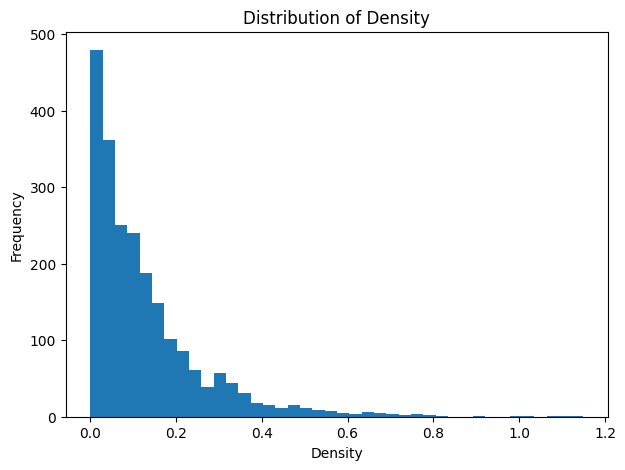

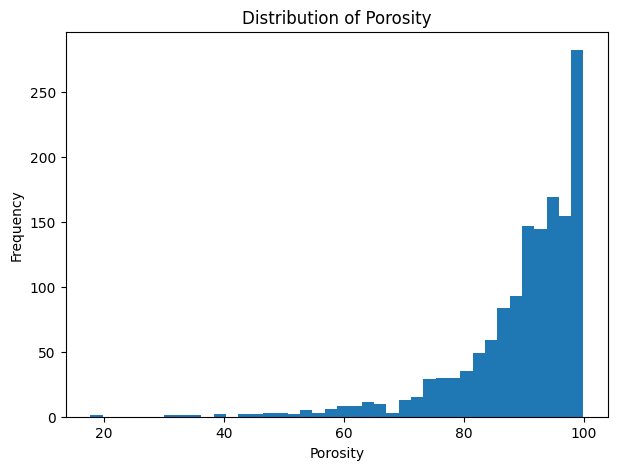

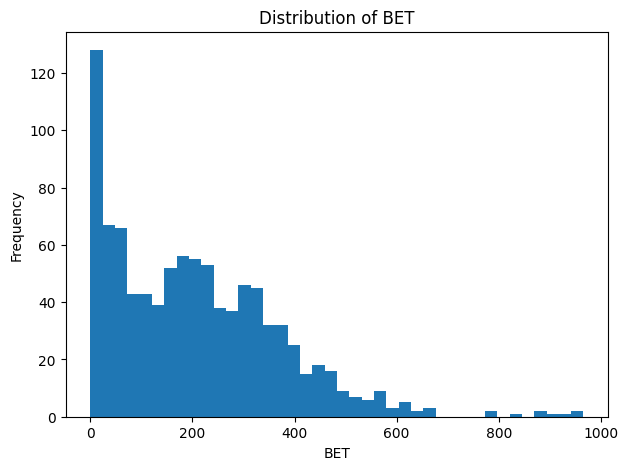

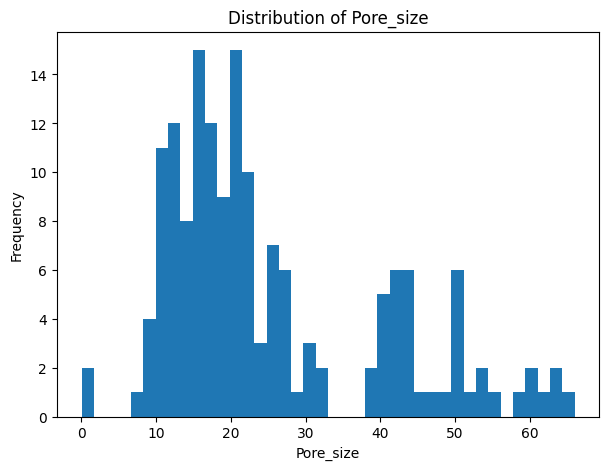

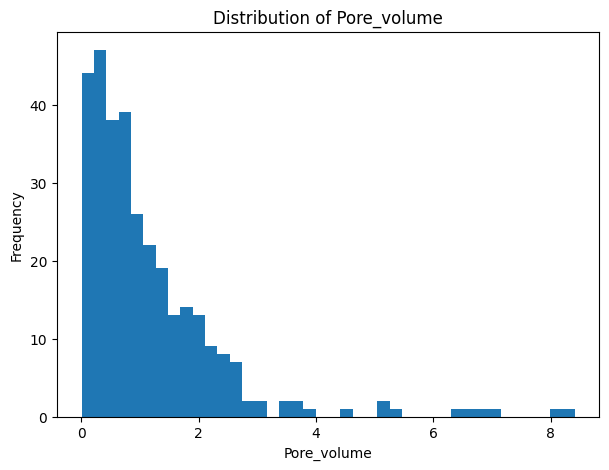

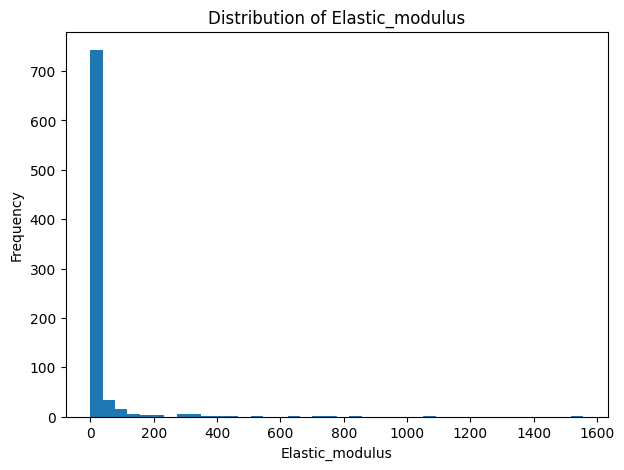

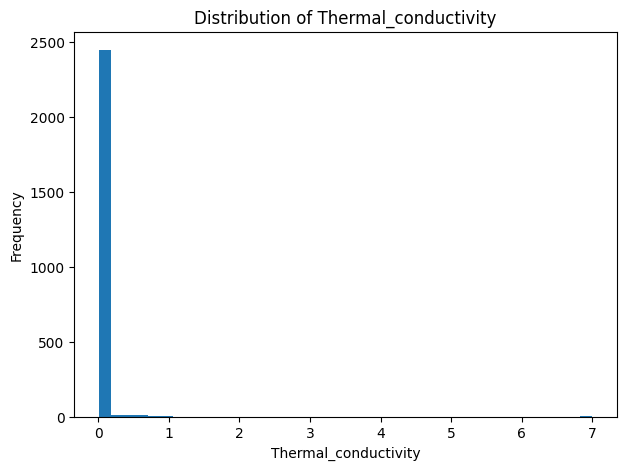

TARGET: Values of thermal conductivity between 0 and 1: 2483
Total values: 2484
Percentage between 0 and 1: 99.96%


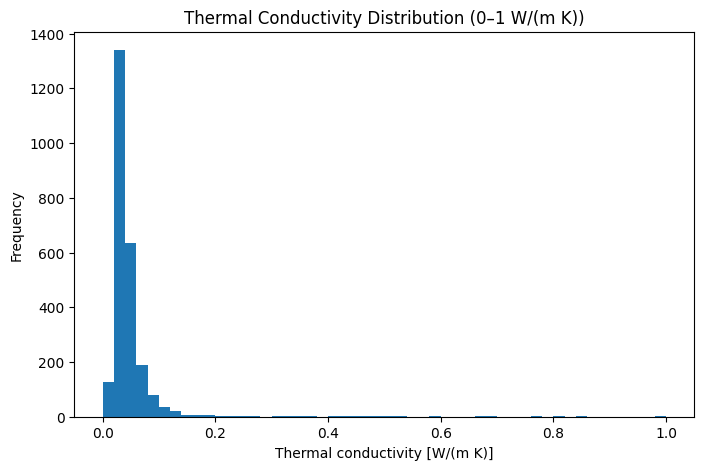

TARGET: Values of thermal conductivity between 0 and 1: 2446
Total values: 2484
Percentage between 0 and 0.2: 98.47%


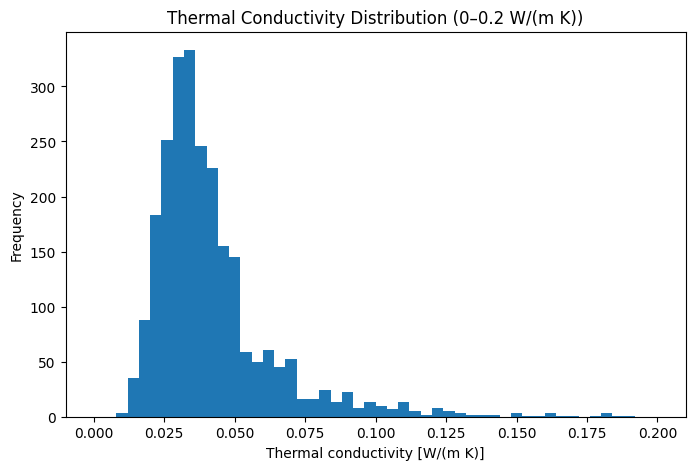

In [83]:
# Basic statistics of the target variable
print(df['Thermal_conductivity'].describe())
numerical_columns = df.select_dtypes(include='float64').columns


for col in numerical_columns:
    plt.figure(figsize=(7, 5))

    plt.hist(df[col].dropna(), bins=40)

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')

    plt.show()

# Count values between 0 and 1
count_0_1 = df['Thermal_conductivity'].between(0, 1).sum()

print(f'TARGET: Values of thermal conductivity between 0 and 1: {count_0_1}')
print(f'Total values: {df["Thermal_conductivity"].notna().sum()}')
print(
    f'Percentage between 0 and 1: '
    f'{count_0_1 / df["Thermal_conductivity"].notna().sum() * 100:.2f}%'
)

plt.figure(figsize=(8, 5))

plt.hist(
    df['Thermal_conductivity'].dropna(),
    bins=50,
    range=(0, 1)
)

# Only one sample has a thermal conductivity above 1 W/(m K).
# This value should be investigated before deciding whether it is an outlier.

plt.xlabel('Thermal conductivity [W/(m K)]')
plt.ylabel('Frequency')
plt.title('Thermal Conductivity Distribution (0–1 W/(m K))')

plt.show()


# Count values between 0 and 0.2
count_0_2 = df['Thermal_conductivity'].between(0, 0.2).sum()

print(f'TARGET: Values of thermal conductivity between 0 and 1: {count_0_2}')
print(f'Total values: {df["Thermal_conductivity"].notna().sum()}')
print(
    f'Percentage between 0 and 0.2: '
    f'{count_0_2 / df["Thermal_conductivity"].notna().sum() * 100:.2f}%'
)

plt.figure(figsize=(8, 5))

plt.hist(
    df['Thermal_conductivity'].dropna(),
    bins=50,
    range=(0, 0.2)
)

# Only 38 sample has a thermal conductivity above 0.2 W/(m K).

plt.xlabel('Thermal conductivity [W/(m K)]')
plt.ylabel('Frequency')
plt.title('Thermal Conductivity Distribution (0–0.2 W/(m K))')

plt.show()


In [84]:
display(df[numerical_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Density,2210.0,0.129133,0.137704,0.0005,0.035000,0.08870,0.170,1.15
Porosity,1405.0,89.493559,10.515960,17.7000,86.000000,92.30000,96.900,99.97
BET,959.0,207.128367,164.915259,0.0630,64.000000,188.00000,310.500,966.00
Pore_size,160.0,25.290625,14.640818,0.0500,15.000000,20.60000,32.700,66.00
Pore_volume,318.0,1.159815,1.245880,0.0030,0.380000,0.80450,1.500,8.41
Elastic_modulus,827.0,25.851266,100.113102,0.0001,0.150000,1.72000,13.250,1557.00
Thermal_conductivity,2484.0,0.050934,0.152535,0.0100,0.028522,0.03655,0.048,7.00


Inspection of the most extreme values in Density and BET shows that they correspond to different materials and processing conditions and are physically plausible.

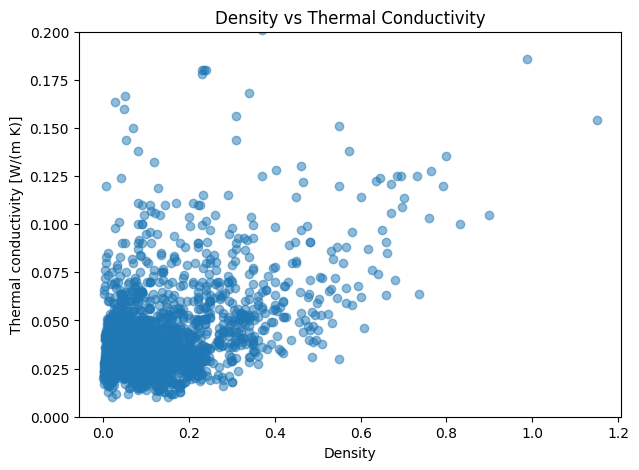

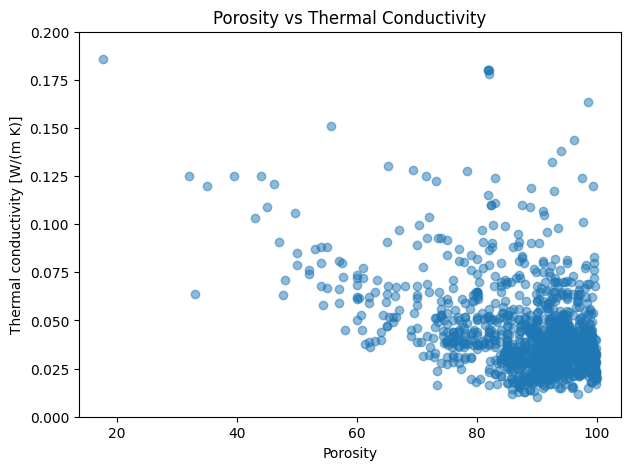

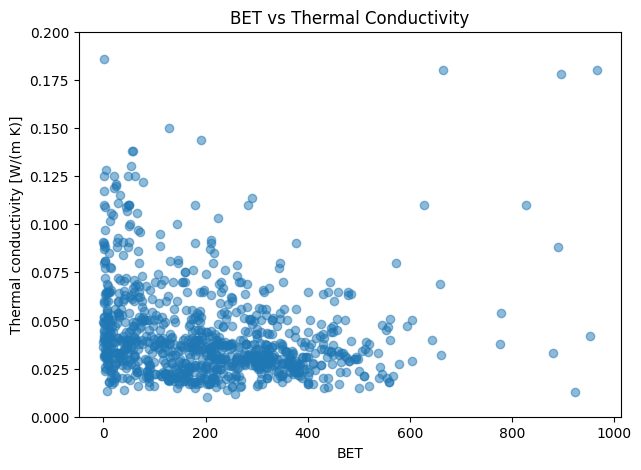

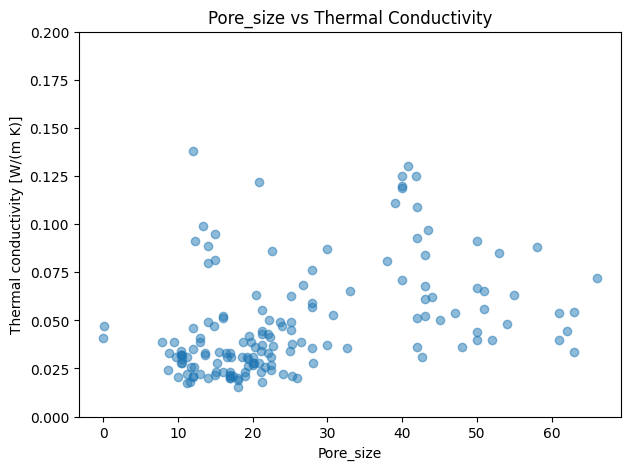

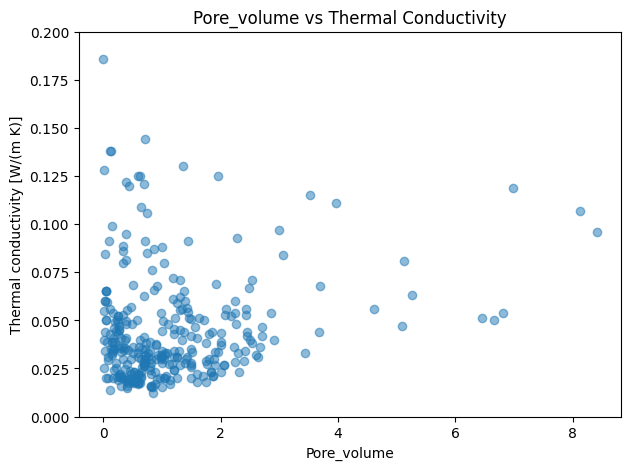

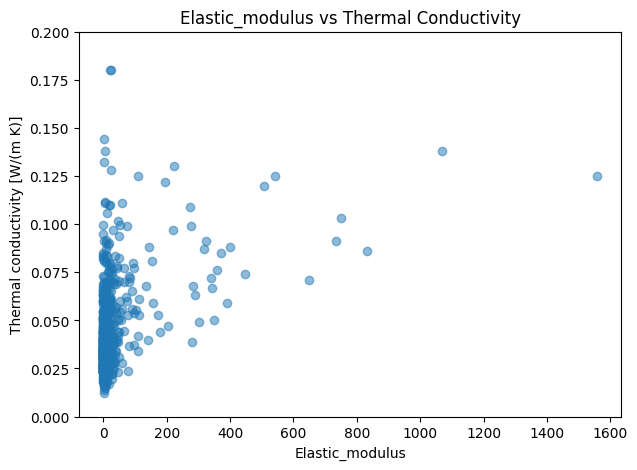

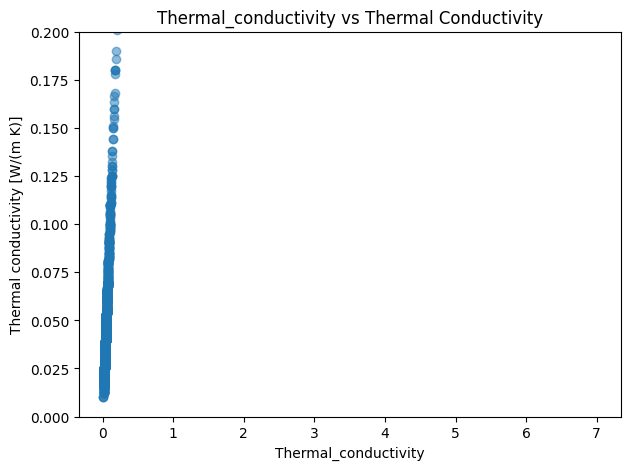

In [85]:
for col in numerical_columns:
    plt.figure(figsize=(7, 5))

    plt.scatter(
        df[col],
        df['Thermal_conductivity'],
        alpha=0.5
    )
    plt.ylim(0, 0.2)
    plt.xlabel(col)
    plt.ylabel('Thermal conductivity [W/(m K)]')
    plt.title(f'{col} vs Thermal Conductivity')

    plt.show()

Some trends can be observed between thermal conductivity, density and porosity.




,Density,Porosity,BET,Pore_size,Pore_volume,Elastic_modulus,Thermal_conductivity
Density,1.000000,-0.908541,-0.168160,0.469941,-0.022974,0.621474,0.293216
Porosity,-0.908541,1.000000,0.213830,-0.541690,0.068288,-0.698242,-0.306439
BET,-0.168160,0.213830,1.000000,-0.317354,0.143587,-0.166333,0.012440
Pore_size,0.469941,-0.541690,-0.317354,1.000000,0.483990,0.002485,0.009292
Pore_volume,-0.022974,0.068288,0.143587,0.483990,1.000000,-0.148083,0.015475
Elastic_modulus,0.621474,-0.698242,-0.166333,0.002485,-0.148083,1.000000,0.421694
Thermal_conductivity,0.293216,-0.306439,0.012440,0.009292,0.015475,0.421694,1.000000


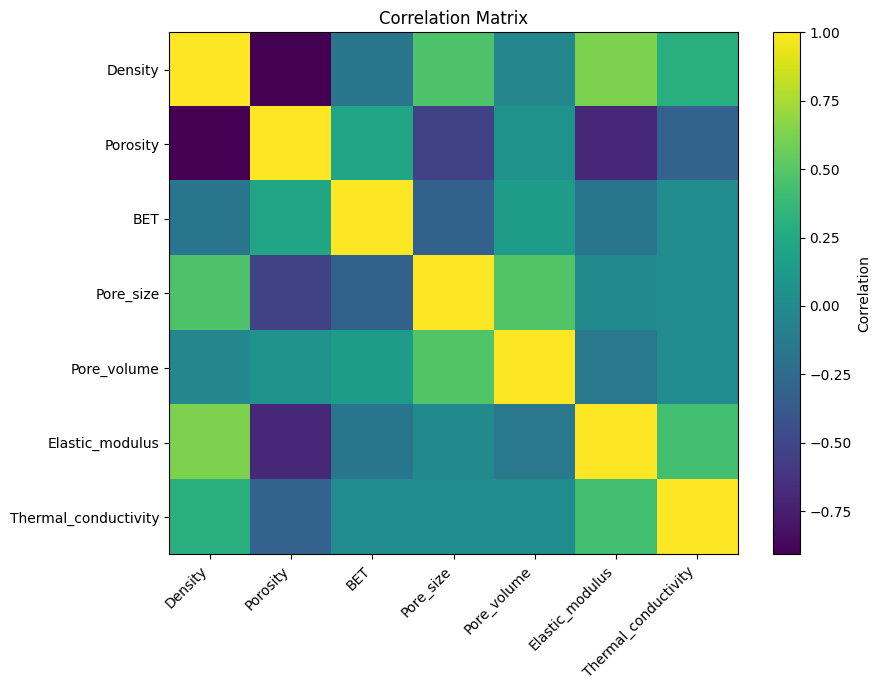

In [86]:
# Correlation matrix to see relations between target and other numerical variables
correlation_matrix = df[numerical_columns].corr()

display(correlation_matrix)

plt.figure(figsize=(9, 7))

plt.imshow(correlation_matrix, aspect='auto')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label='Correlation')

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [87]:
# EDA Conclusions
#
# - Thermal conductivity is strongly right-skewed, with 99.96% of the measured
#   values between 0 and 1 W/(m K).
# - One sample has a thermal conductivity of 7 W/(m K) and should be investigated
#   before deciding whether it is a valid measurement or an outlier.
# - Density and porosity show visible trends with thermal conductivity.
# - The correlation matrix shows moderate relationships between thermal conductivity
#   and density, porosity and elastic modulus.
# - Density and porosity are strongly negatively correlated (-0.91), which should
#   be considered when developing the ML models.
# - BET, pore size, pore volume and elastic modulus contain substantial missing data,
#   which will need to be addressed during preprocessing.

In [88]:
# Inspect the sample with thermal conductivity = 7

display(
    df[df['Thermal_conductivity'] == 7].T
)

,6642
Entry,6643
Drying,FD
Purpose,Not specific
Shape,Monolith
First materials,GO
Second materials,Epoxy
Modification,Carbonized
First material class,N
Second materials class,F
Modification class,Ca


In [89]:
# Find samples with similar material and thermal measurement method

similar_samples = df[
    (df['First materials'] == 'GO') &
    (df['Thermal method detail'] == 'Flash')
].sort_values('Thermal_conductivity', ascending=False)

display(
    similar_samples[
        [
            'Entry',
            'Drying',
            'First materials',
            'Second materials',
            'Modification',
            'Shape',
            'Thermal_conductivity',
            'Thermal method',
            'Thermal method detail'
        ]
    ]
)


,Entry,Drying,First materials,Second materials,Modification,Shape,Thermal_conductivity,Thermal method,Thermal method detail
6642,6643,FD,GO,Epoxy,Carbonized,Monolith,7.000,Transient,Flash
6641,6642,FD,GO,Epoxy,NaN,Monolith,1.000,Transient,Flash
4518,4519,FD,GO,Polyamide,NaN,Monolith,0.847,Transient,Flash
6475,6476,FD,GO,Cellulose,NaN,Monolith,0.670,Transient,Flash
10909,10910,FD,GO,"PVA, epoxy",NaN,Monolith,0.592,Transient,Flash
10908,10909,FD,GO,"PVA, epoxy",NaN,Monolith,0.493,Transient,Flash


In [90]:
carbonized = df[
    df['Modification'].str.contains('Carbonized', case=False, na=False)
].sort_values('Thermal_conductivity', ascending=False)

display(
    carbonized[
        [
            'Entry',
            'Drying',
            'First materials',
            'Second materials',
            'Modification',
            'Shape',
            'Thermal_conductivity',
            'Thermal method',
            'Thermal method detail',
            'Density',
            'Purpose'
        ]
    ]
)

,Entry,Drying,First materials,Second materials,Modification,Shape,Thermal_conductivity,Thermal method,Thermal method detail,Density,Purpose
6642,6643,FD,GO,Epoxy,Carbonized,Monolith,7.00000,Transient,Flash,NaN,Not specific
9731,9732,APD,RF,NaN,Carbonized,Monolith,0.15440,Steady state,GHP,1.15000,Not specific
9719,9720,APD,RF,NaN,Carbonized,Monolith,0.13560,Steady state,GHP,0.80000,Not specific
9730,9731,APD,RF,NaN,Carbonized,Monolith,0.12000,Steady state,GHP,0.55000,Not specific
9728,9729,APD,RF,NaN,Carbonized,Monolith,0.11390,Steady state,GHP,0.60000,Not specific
9732,9733,APD,RF,NaN,Carbonized,Monolith,0.11390,Steady state,GHP,0.45000,Not specific
9725,9726,APD,RF,NaN,Carbonized,Monolith,0.10490,Steady state,GHP,0.90000,Not specific
9724,9725,APD,RF,NaN,Carbonized,Monolith,0.09860,Steady state,GHP,0.40000,Not specific
9722,9723,APD,RF,NaN,Carbonized,Monolith,0.09710,Steady state,GHP,0.65000,Not specific
9733,9734,APD,RF,NaN,Carbonized,Monolith,0.07610,Steady state,GHP,0.35000,Not specific


The value of 7.000 W/m·K initially appeared as a strong outlier compared with most other samples in the dataset, including other samples labelled as "Carbonized". However, further investigation showed that high thermal conductivity values can be physically plausible for graphene-based aerogels when the carbon structure is highly graphitized and/or structurally aligned.

In particular, literature reports thermal conductivities in the range of several W/m·K for highly graphitized and directionally aligned graphene aerogels, which is substantially higher than the values typically observed for conventional, disordered porous carbon aerogels.

Therefore, the value cannot be considered a data-entry error based on its magnitude alone. Instead, it highlights a limitation of the current categorical representation: the "Modification" variable groups potentially very different processes under the same label, such as conventional carbonization and high-temperature graphitization.

The value was therefore retained in the dataset. For the subsequent modelling stage, extreme-value analysis should consider material type, processing conditions and measurement method rather than applying a single global threshold to thermal conductivity.

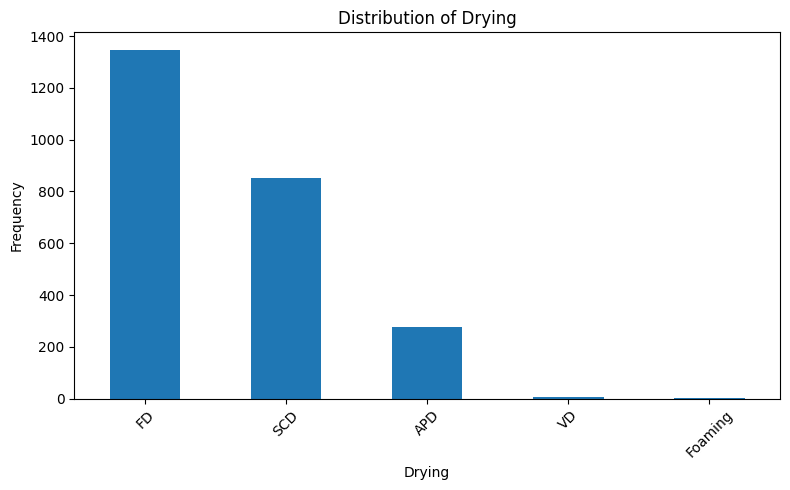

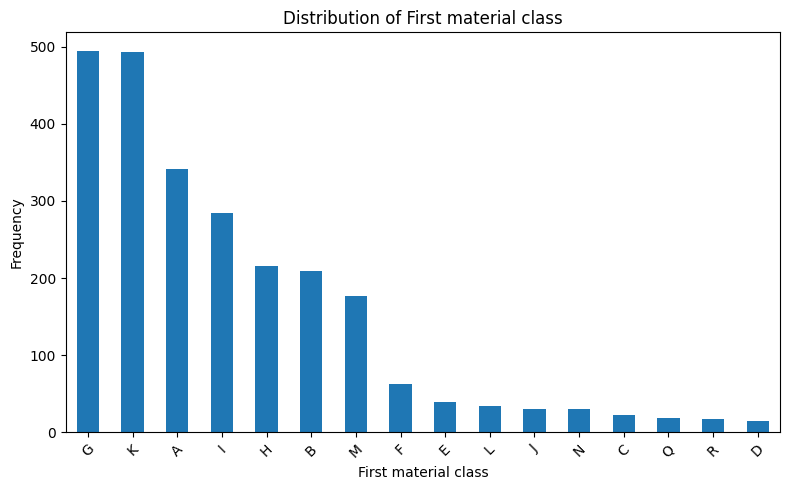

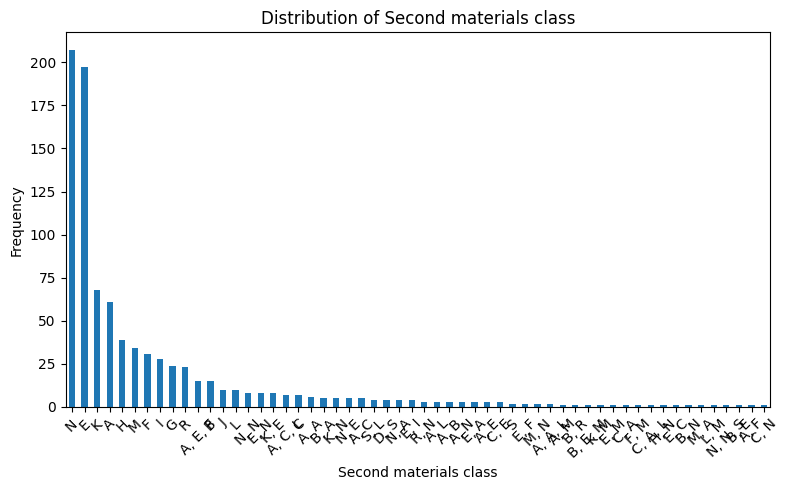

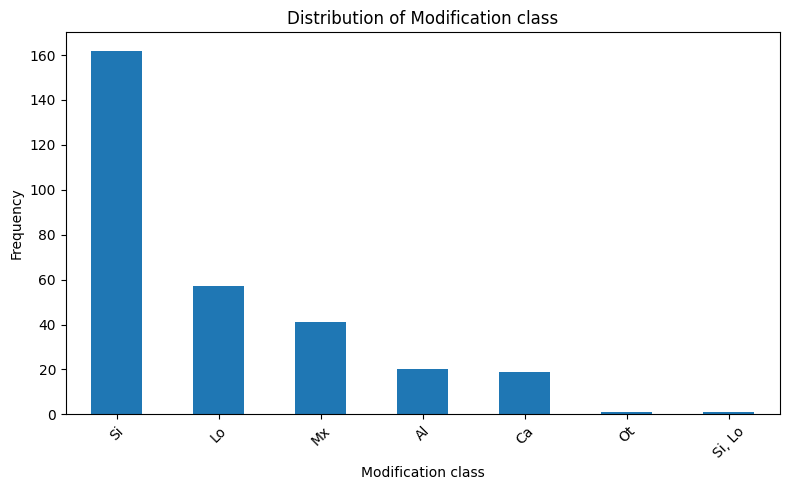

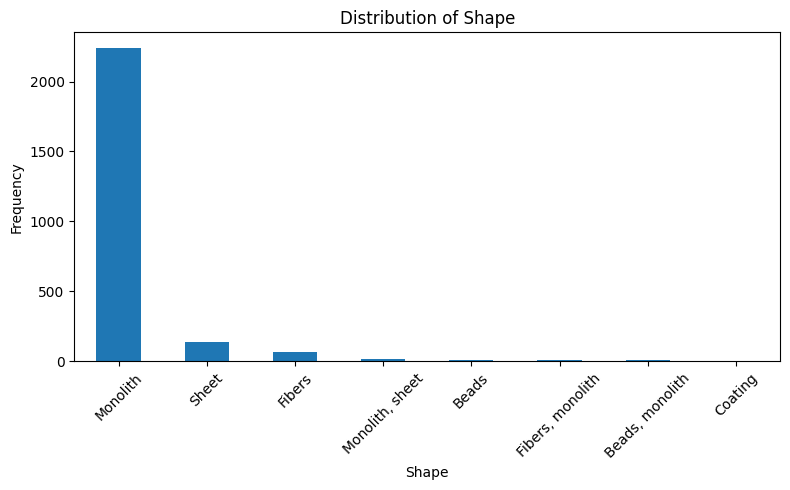

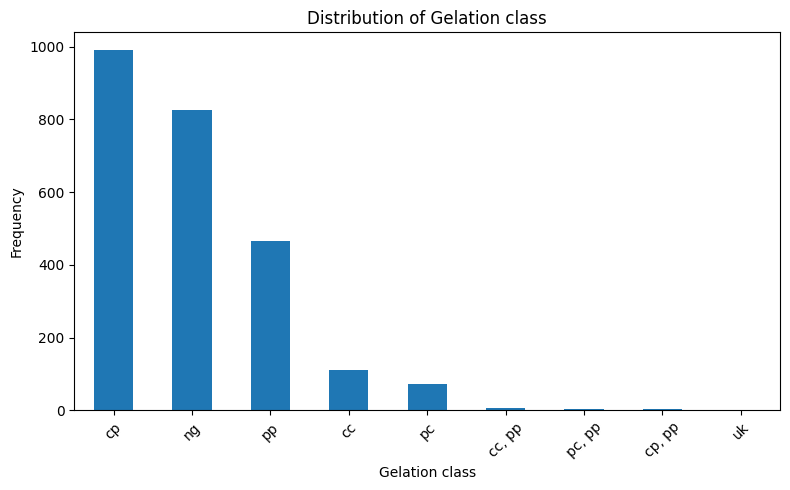

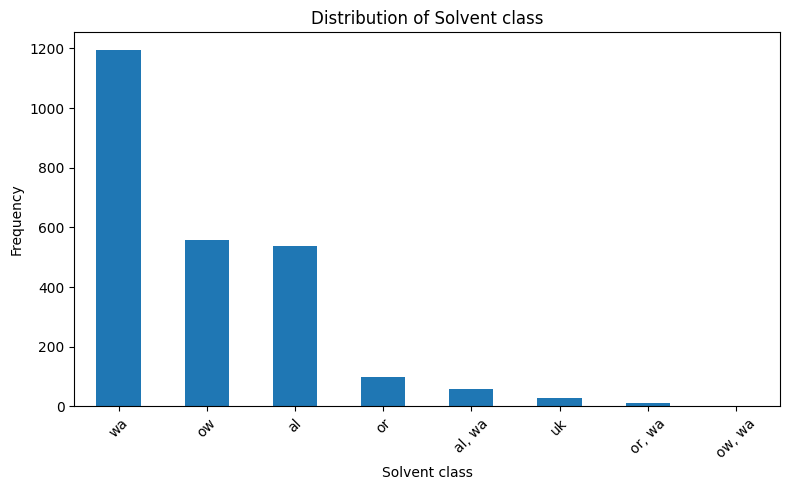

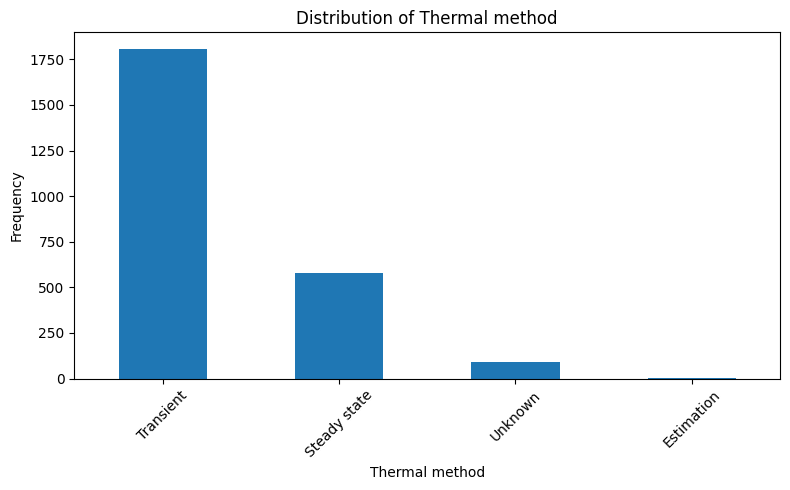

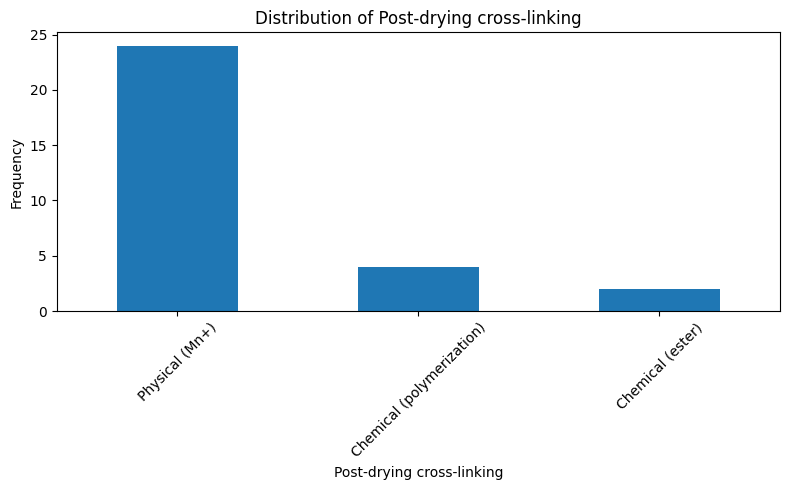

In [91]:
categorical_features=[
    'Drying',
    'First material class',
    'Second materials class',
    'Modification class',
    'Shape',
    'Gelation class',
    'Solvent class',
    'Thermal method',
    'Post-drying cross-linking'
]

for col in categorical_features:
    plt.figure(figsize=(8, 5))

    df[col].value_counts().plot(kind='bar')

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

In [92]:
for col in categorical_features:

    print(f'\n--- {col} ---')

    summary = (
        df.groupby(col)['Thermal_conductivity']
        .agg(['count', 'mean', 'median', 'std'])
        .sort_values('count', ascending=False)
    )

    display(summary)


--- Drying ---


,count,mean,median,std
Drying,,,,
FD,1347,0.056684,0.0380,0.203087
SCD,851,0.039246,0.0301,0.044417
APD,276,0.058938,0.0480,0.038046
VD,7,0.038669,0.0422,0.006972
Foaming,3,0.077333,0.0760,0.004163



--- First material class ---


,count,mean,median,std
First material class,,,,
G,494,0.040040,0.03503,0.017546
K,493,0.046750,0.03500,0.067658
A,342,0.042801,0.03900,0.023401
I,285,0.047394,0.03700,0.037291
H,216,0.043498,0.03690,0.023948
B,209,0.048747,0.03600,0.051776
M,177,0.060495,0.04110,0.069490
F,63,0.033252,0.03120,0.012672
E,39,0.043215,0.03600,0.018677



--- Second materials class ---


...

,count,mean,median,std
Solvent class,,,,
wa,1194,0.058626,0.03850,0.215492
ow,557,0.038408,0.03200,0.021242
al,537,0.047437,0.03427,0.053035
or,100,0.048229,0.03800,0.028962
"al, wa",58,0.045759,0.04020,0.017829
uk,27,0.070636,0.03970,0.112298
"or, wa",10,0.025520,0.02600,0.004972
"ow, wa",1,0.015800,0.01580,NaN



--- Thermal method ---


,count,mean,median,std
Thermal method,,,,
Transient,1808,0.056032,0.0384,0.177885
Steady state,581,0.036088,0.0290,0.024231
Unknown,92,0.045044,0.0370,0.028374
Estimation,3,0.034800,0.0300,0.008839



--- Post-drying cross-linking ---


,count,mean,median,std
Post-drying cross-linking,,,,
Physical (Mn+),24,0.061788,0.03755,0.061177
Chemical (polymerization),4,0.037750,0.03750,0.001708
Chemical (ester),2,0.029500,0.02950,0.006364


<Figure size 1000x500 with 0 Axes>

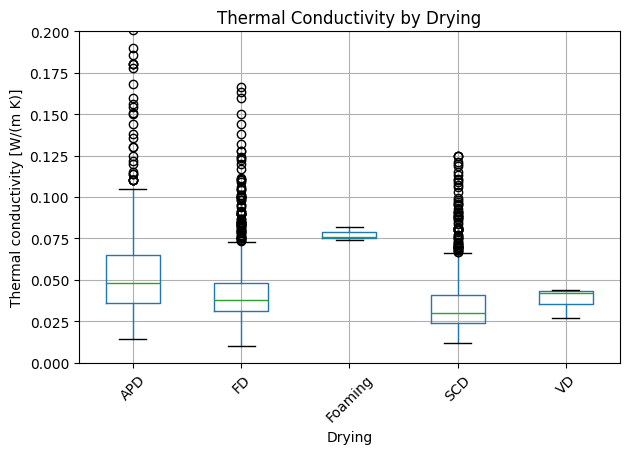

<Figure size 1000x500 with 0 Axes>

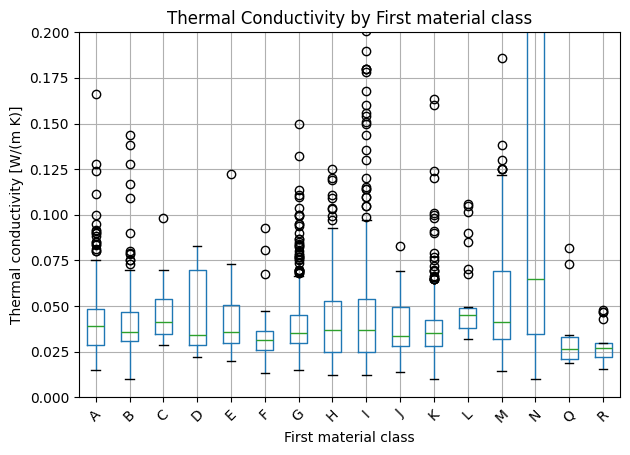

<Figure size 1000x500 with 0 Axes>

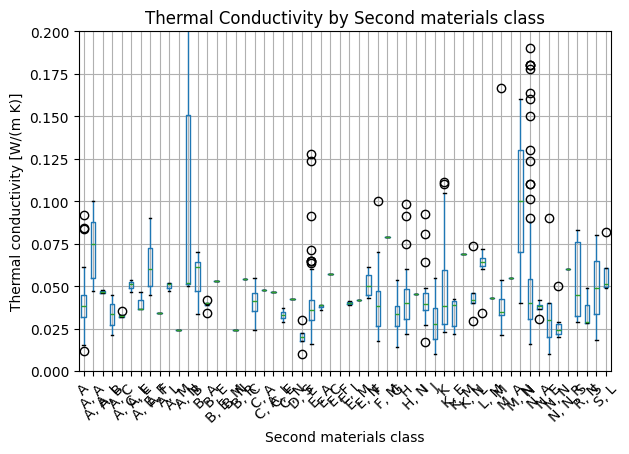

<Figure size 1000x500 with 0 Axes>

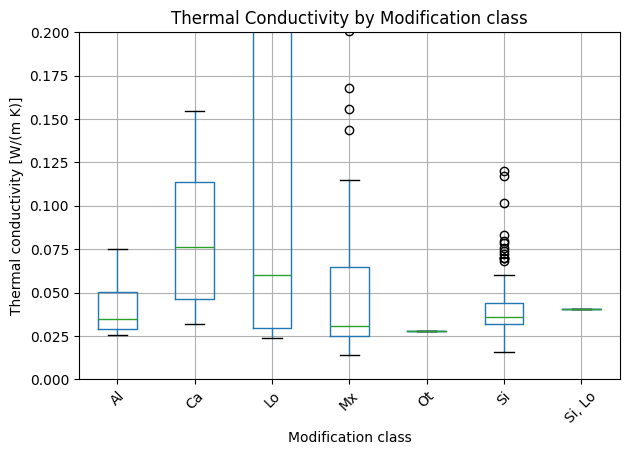

<Figure size 1000x500 with 0 Axes>

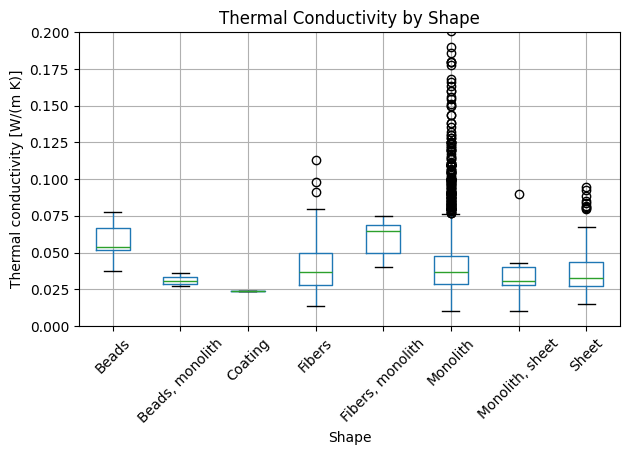

<Figure size 1000x500 with 0 Axes>

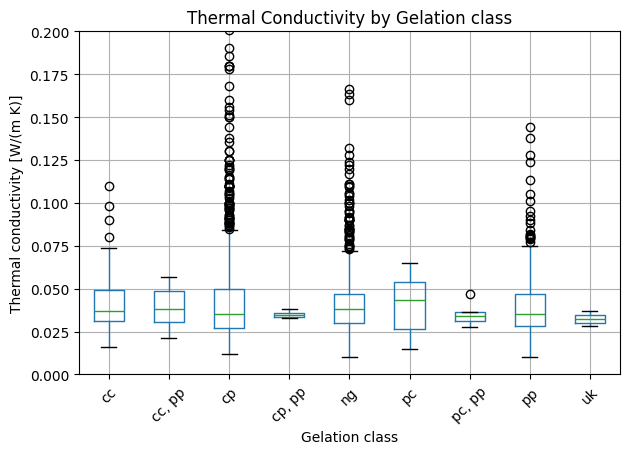

<Figure size 1000x500 with 0 Axes>

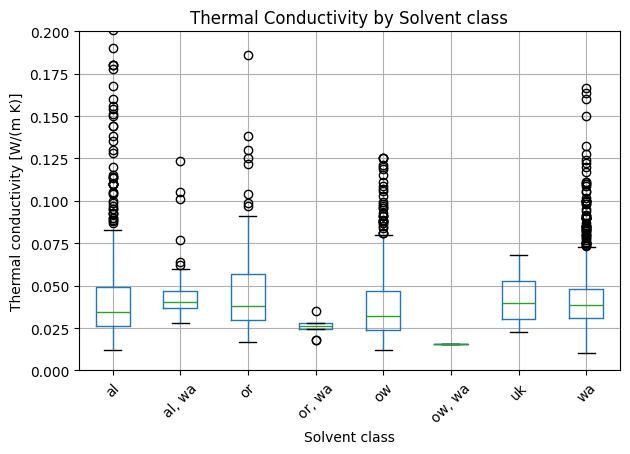

<Figure size 1000x500 with 0 Axes>

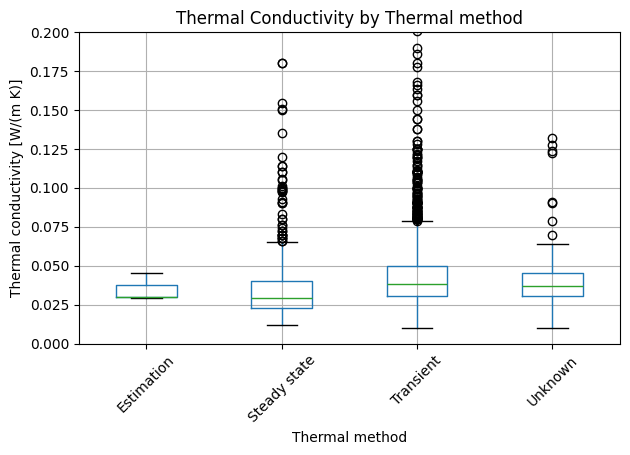

<Figure size 1000x500 with 0 Axes>

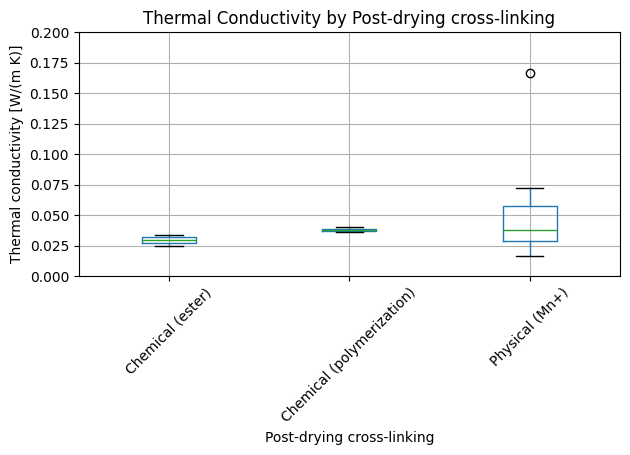

In [93]:
for col in categorical_features:
    plt.figure(figsize=(10, 5))

    df.boxplot(
        column='Thermal_conductivity',
        by=col
    )
    plt.ylim(0, 0.2)
    plt.xlabel(col)
    plt.ylabel('Thermal conductivity [W/(m K)]')
    plt.title(f'Thermal Conductivity by {col}')

    plt.suptitle('')
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

Some Shape values contain multiple forms (e.g., "Monolith, sheet"). Treating them as single categories is not an ideal representation. We will address this later by converting Shape into separate binary features. This also happens to other features like purpose.

In [94]:
# Categorical EDA Conclusions
#
# - Drying, Shape, Thermal method and the class variables show different
#   distributions of samples across their categories.
# - The boxplots suggest that thermal conductivity may vary between some
#   categorical groups, although several categories contain relatively few
#   observations.
# - Shape contains multi-label categories such as "Monolith, sheet" and
#   "Fibers, monolith", which should be transformed into separate binary
#   features during feature engineering.
# - Purpose, material and modification variables contain many categories,
#   so their representation should be considered carefully before encoding.
# - Process contains a very large number of unique values and should not be
#   directly one-hot encoded.
# - Some categorical variables contain class/group information that may provide
#   a more compact representation of the original material or modification
#   information.

Overall conclusion:
The main candidate features identified at this stage are density, porosity,
BET, drying method, shape and material information. Further feature engineering and preprocessing are required before training the first ML models.





EDA
│
├── Target
│   ├── Statistics
│   ├── Distribution
│   ├── 0–1 distribution
│   └── Investigate value = 7
│
├── Numerical features
│   ├── Statistics
│   ├── Scatter plots
│   └── Correlation matrix       ← añadir
│
├── Categorical features
│   ├── Frequency
│   └── Target vs category
│       ├── Drying
│       └── Shape
│
└── Feature engineering
    └── Más adelante
        ├── Shape multilabel
        ├── Purpose multilabel
        ├── Materials vs classes
        └── etc.

# FEATURE ENGINEERING

In [95]:
# Check the categories present in Shape
print("Shape categories:")
print(df['Shape'].unique())

Shape categories:
['Monolith' 'Fibers, monolith' 'Sheet' 'Fibers' 'Monolith, sheet'
 'Beads, monolith' 'Beads' 'Coating']


In [96]:
# Normalize capitalization within multi-label Shape values

shape_corrections = {
    'monolith': 'Monolith',
    'sheet': 'Sheet',
    'fibers': 'Fibers',
    'beads': 'Beads',
    'coating': 'Coating'
}

df['Shape'] = (
    df['Shape']
    .str.split(', ')
    .apply(
        lambda x: ', '.join(
            shape_corrections.get(item.strip().lower(), item.strip())
            for item in x
        ) if isinstance(x, list) else x
    )
)
print(df['Shape'].unique())

['Monolith' 'Fibers, Monolith' 'Sheet' 'Fibers' 'Monolith, Sheet'
 'Beads, Monolith' 'Beads' 'Coating']


In [97]:
# Feature Engineering: convert Shape into binary features
shape_features = df['Shape'].str.get_dummies(sep=', ')

# Add prefix to the new features
shape_features = shape_features.add_prefix('Shape_')

# Add the new features to the dataframe
df = pd.concat([df, shape_features], axis=1)

In [98]:
# Check the number of samples for each shape feature

shape_columns = [
    col for col in df.columns
    if col.startswith('Shape_')
]

display(df[shape_columns].sum().sort_values(ascending=False))

,0
Shape_Monolith,2268
Shape_Sheet,153
Shape_Fibers,73
Shape_Beads,17
Shape_Coating,1


In [99]:

numeric_features = [
    'Density',
    'Porosity',
    'BET',
    'Pore_size',
    'Pore_volume',
    'Elastic_modulus'
]
categorical_features = [
    'Drying',
    'First material class',
    'Second materials class',
    'Modification class',
    'Gelation class',
    'Solvent class',
    'Thermal method',
    'Post-drying cross-linking'
]

target = 'Thermal_conductivity'

X = df[numeric_features + categorical_features + shape_columns]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

X shape: (2484, 19)
y shape: (2484,)
Training set: (1987, 19)
Test set: (497, 19)


# PREPROCESSING

In [102]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        (
            "shape",
            "passthrough",
            shape_columns
        )
    ]
)